In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option('display.max_columns',None)

In [ ]:
df = pd.read_csv("/content/gurgaon_properties_cleaned_v2.csv")

In [ ]:
df.head()

,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,latitude,longitude
0,dlf the magnolias,Sector 42,45.00,70312.0,6400,Super Built-up area 6400(594.58 sq.m.)Built-up...,4,4,3+,14,North-East,Moderately Old,6400.0,6000.00,5400.0,1,1,0,1,1,Furnished,1,28.454042,77.098740
1,godrej meridien,Sector 106,2.85,15364.0,1855,Super Built-up area 1855(172.34 sq.m.) sqft,3,3,3,8,East,Relatively New,1855.0,NaN,NaN,1,1,0,1,1,Unknown,5,28.508181,76.986806
2,experion windchants,Sector 112,6.25,16609.0,3763,Super Built-up area 3763(349.59 sq.m.)Built-up...,3,5,3,6,North,Moderately Old,3763.0,2873.18,NaN,0,1,0,0,0,Semi-Furnished,0,28.518719,77.014458
3,godrej 101,Sector 79,3.50,16471.0,2125,Super Built-up area 2125(197.42 sq.m.)Carpet a...,3,3,3,11,North,Under Construction,2125.0,NaN,1141.0,0,1,0,0,0,Unknown,0,28.359337,76.969227
4,dlf new town heights 1,Sector 90,2.85,10451.0,2727,Super Built-up area 2727(253.35 sq.m.)Built-up...,4,4,3+,4,North-West,Moderately Old,2727.0,2725.00,2721.0,0,1,0,1,0,Semi-Furnished,21,28.403442,76.930775


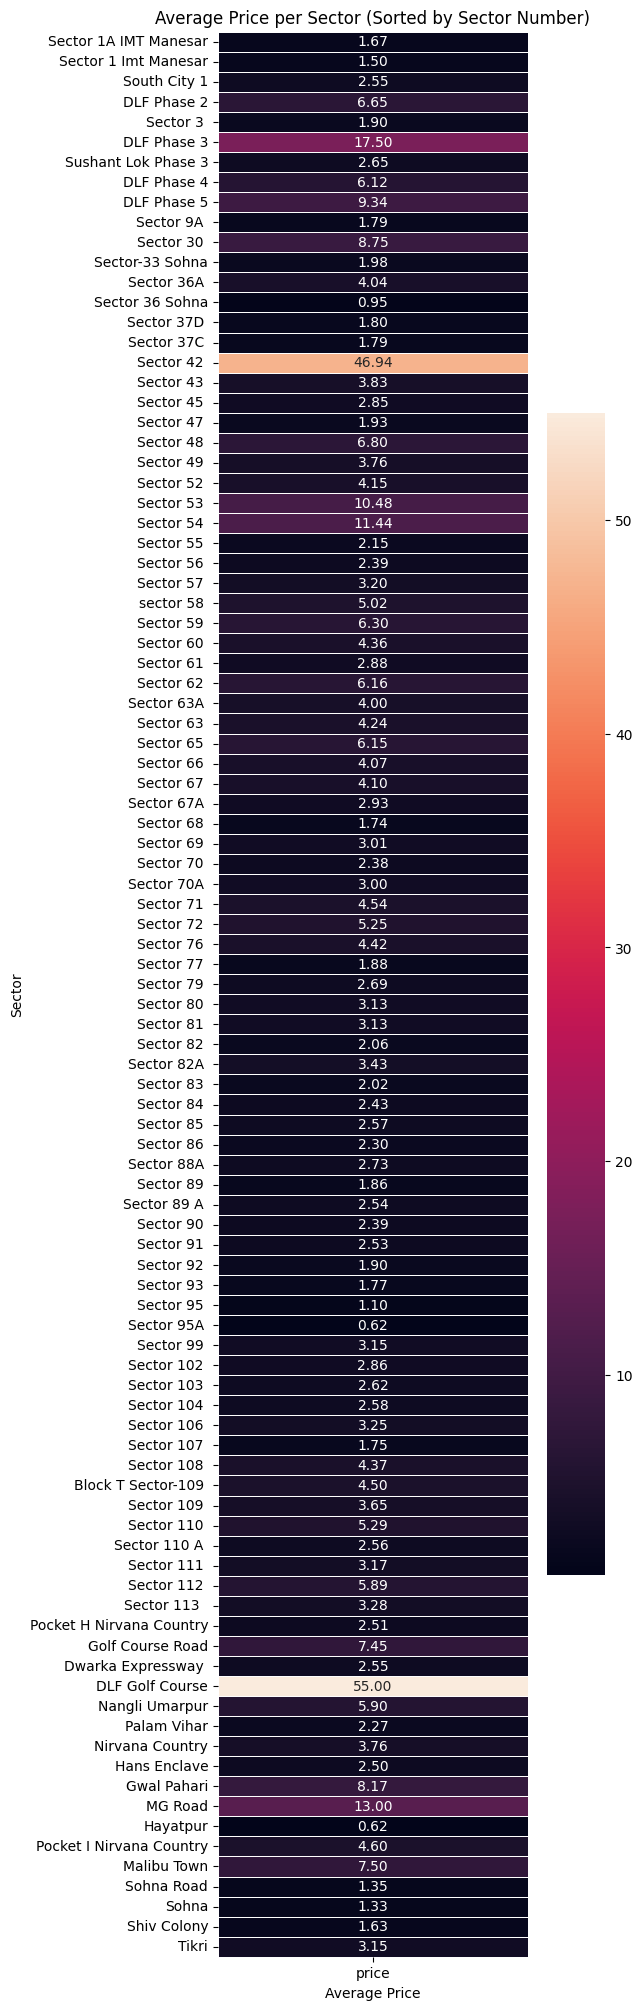

In [ ]:
# sector analysis
import re
# Group by 'sector' and calculate the average price
avg_price_per_sector = df.groupby('sector')['price'].mean().reset_index()

# Function to extract sector numbers
def extract_sector_number(sector_name):
    match = re.search(r'\d+', sector_name)
    if match:
        return int(match.group())
    else:
        return float('inf')  # Return a large number for non-numbered sectors

avg_price_per_sector['sector_number'] = avg_price_per_sector['sector'].apply(extract_sector_number)

# Sort by sector number
avg_price_per_sector_sorted_by_sector = avg_price_per_sector.sort_values(by='sector_number')

# Plot the heatmap
plt.figure(figsize=(5, 25))
sns.heatmap(avg_price_per_sector_sorted_by_sector.set_index('sector')[['price']], annot=True, fmt=".2f", linewidths=.5)
plt.title('Average Price per Sector (Sorted by Sector Number)')
plt.xlabel('Average Price')
plt.ylabel('Sector')
plt.show()

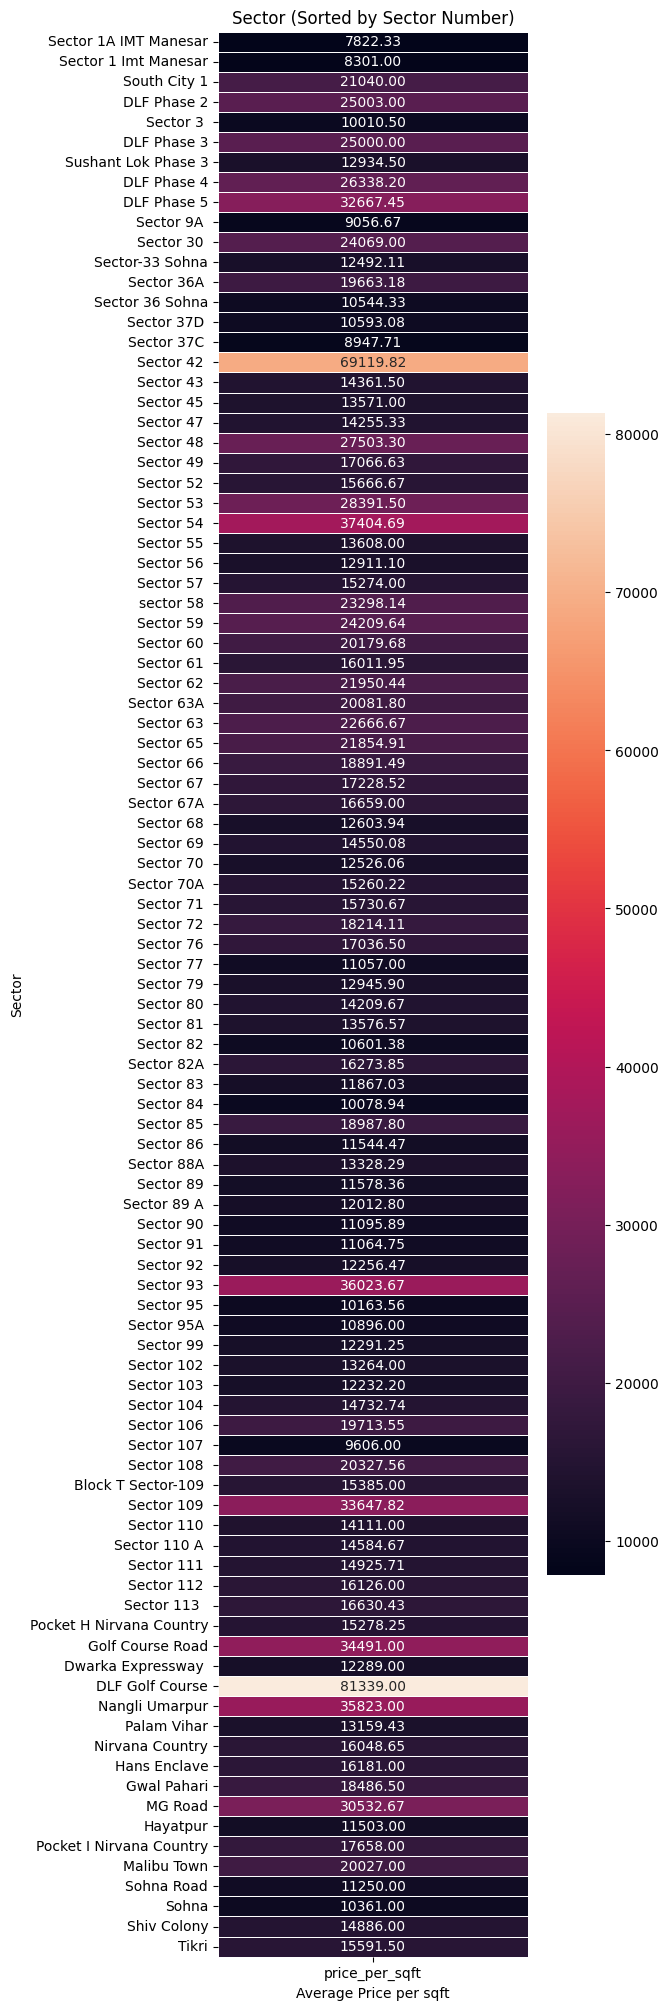

In [ ]:
avg_price_per_sqft_sector = df.groupby('sector')['price_per_sqft'].mean().reset_index()

avg_price_per_sqft_sector['sector_number'] = avg_price_per_sqft_sector['sector'].apply(extract_sector_number)

# Sort by sector number
avg_price_per_sqft_sector_sorted_by_sector = avg_price_per_sqft_sector.sort_values(by='sector_number')

# Plot the heatmap
plt.figure(figsize=(5, 25))
sns.heatmap(avg_price_per_sqft_sector_sorted_by_sector.set_index('sector')[['price_per_sqft']], annot=True, fmt=".2f", linewidths=.5)
plt.title('Sector (Sorted by Sector Number)')
plt.xlabel('Average Price per sqft')
plt.ylabel('Sector')
plt.show()

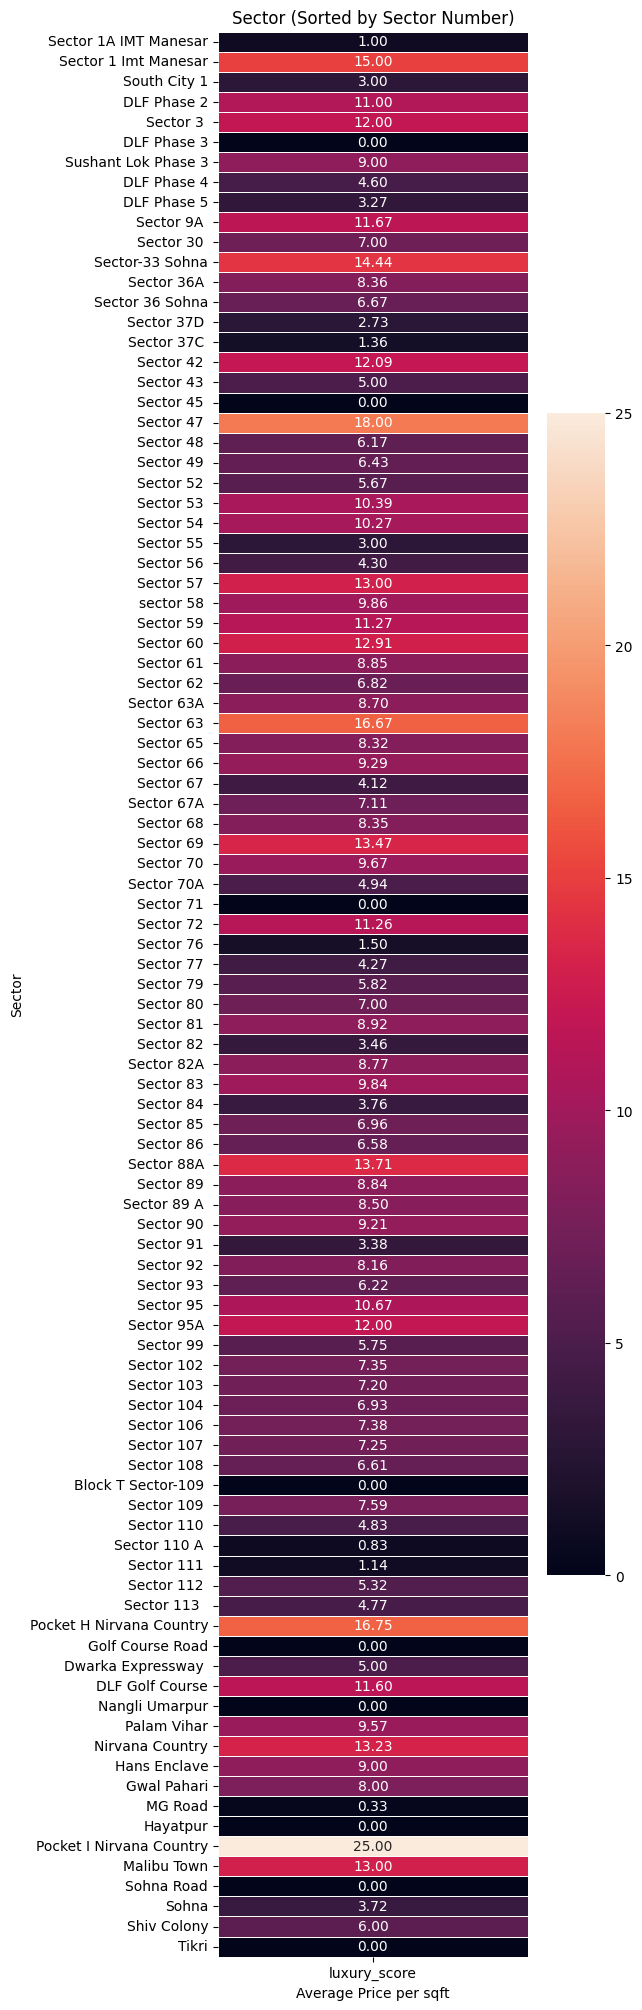

In [ ]:
luxury_score = df.groupby('sector')['luxury_score'].mean().reset_index()

luxury_score['sector_number'] = luxury_score['sector'].apply(extract_sector_number)

# Sort by sector number
luxury_score_sector = luxury_score.sort_values(by='sector_number')

# Plot the heatmap
plt.figure(figsize=(5, 25))
sns.heatmap(luxury_score_sector.set_index('sector')[['luxury_score']], annot=True, fmt=".2f", linewidths=.5)
plt.title('Sector (Sorted by Sector Number)')
plt.xlabel('Average Price per sqft')
plt.ylabel('Sector')
plt.show()

##**price**

<Axes: xlabel='area', ylabel='price'>

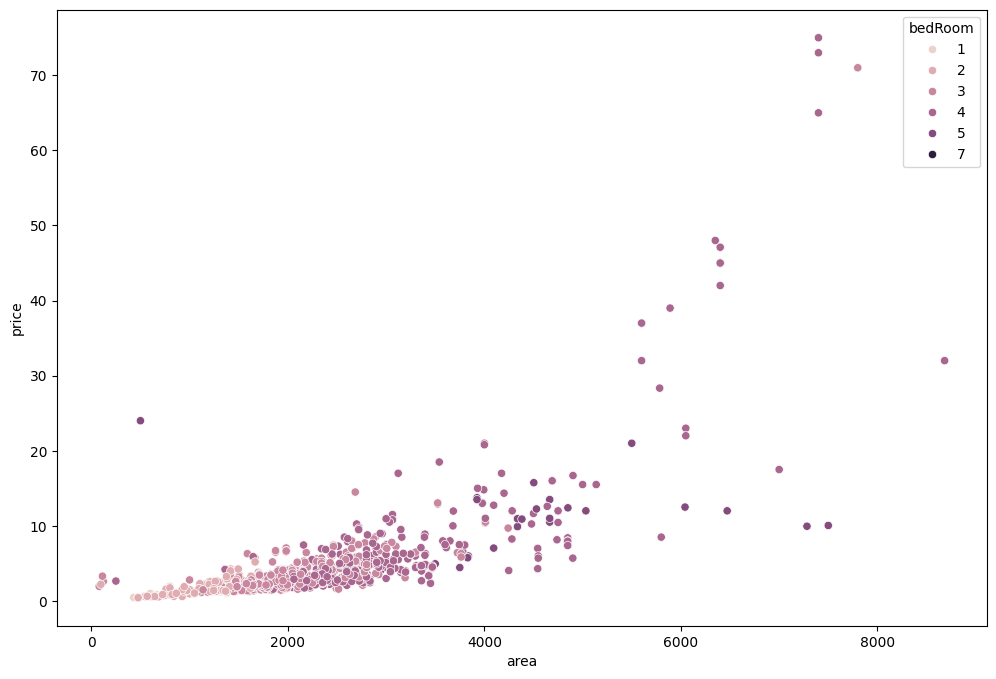

In [ ]:
plt.figure(figsize=(12,8))
sns.scatterplot(data = df, x = df[df['area']<10000]['area'],y = df['price'],hue=df['bedRoom'])

<Axes: xlabel='area', ylabel='price'>

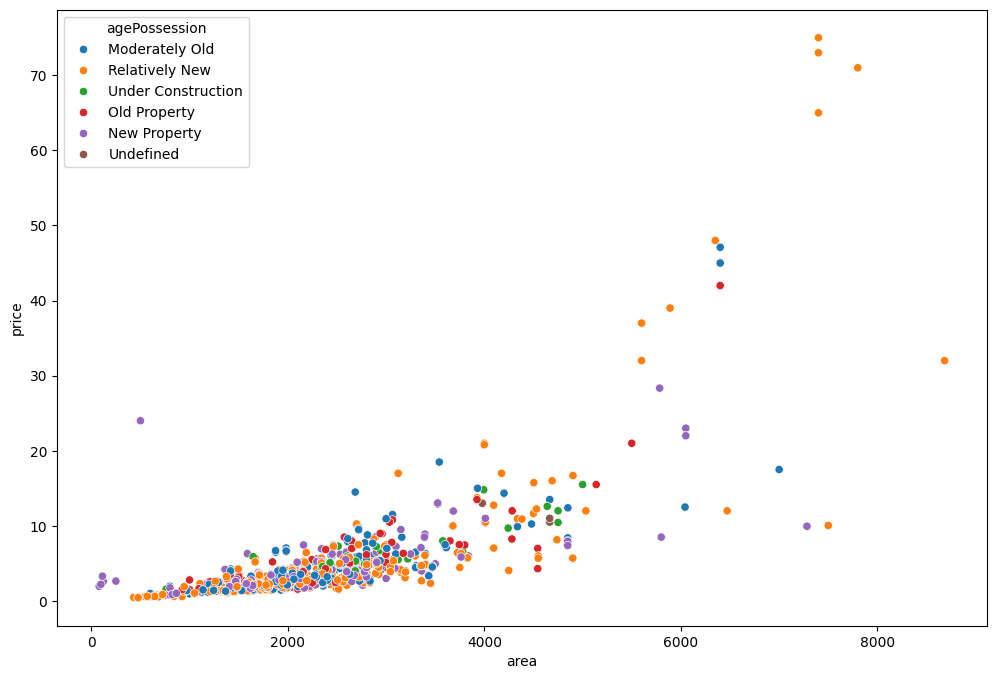

In [ ]:
plt.figure(figsize=(12,8))
sns.scatterplot(data = df, x = df[df['area']<10000]['area'],y = df['price'],hue=df['agePossession'])

<Axes: xlabel='area', ylabel='price'>

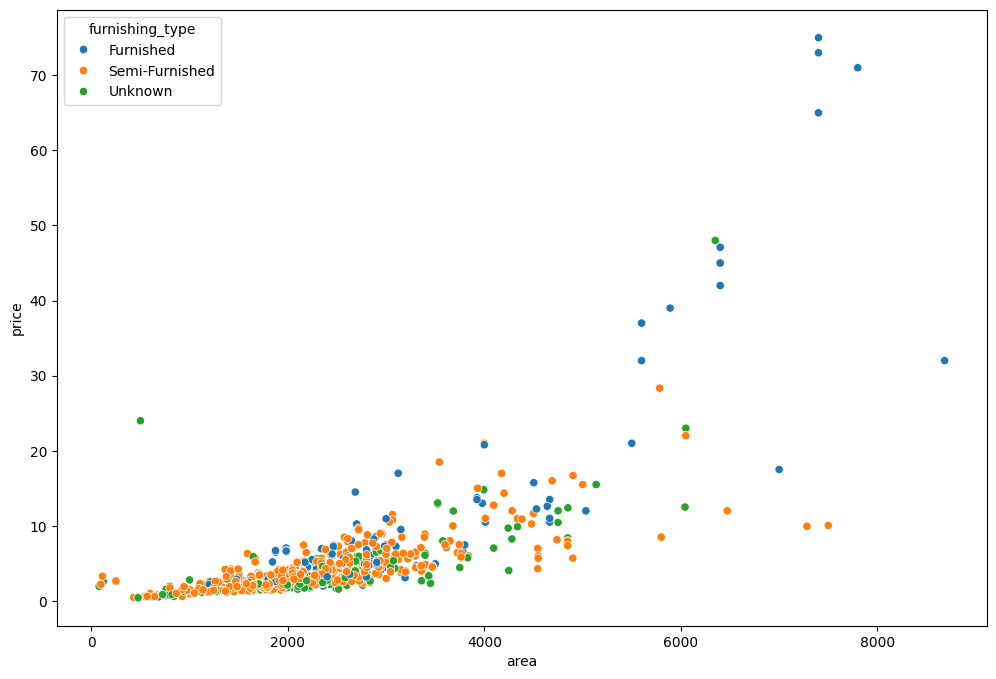

In [ ]:
plt.figure(figsize=(12,8))
sns.scatterplot(data = df, x = df[df['area']<10000]['area'],y = df['price'],hue=df['furnishing_type'].astype('category'))

<Axes: xlabel='bedRoom', ylabel='price'>

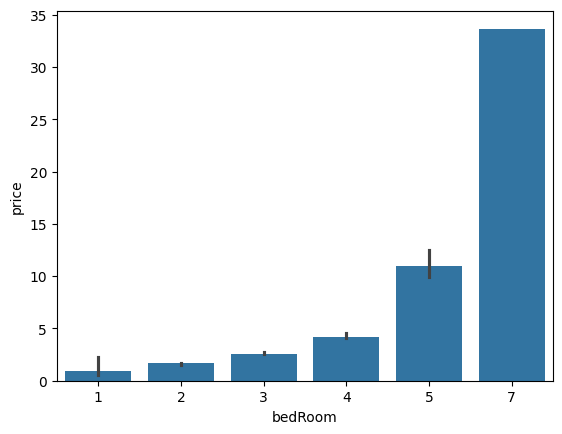

In [ ]:
sns.barplot(x=df['bedRoom'], y=df['price'],estimator=np.median)

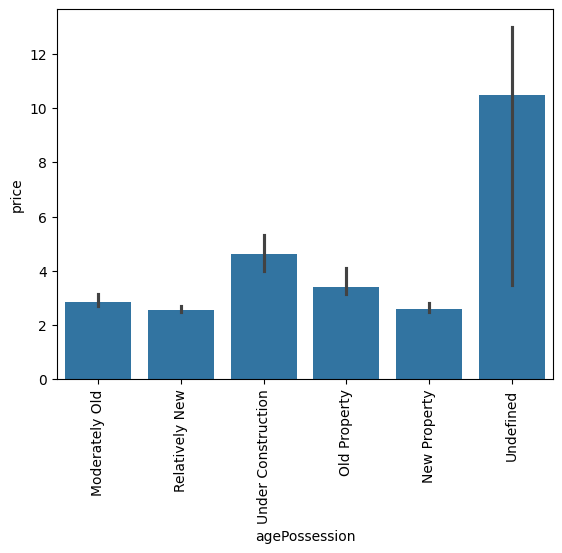

In [ ]:
sns.barplot(x=df['agePossession'],y=df['price'],estimator=np.median)
plt.xticks(rotation='vertical')
plt.show()

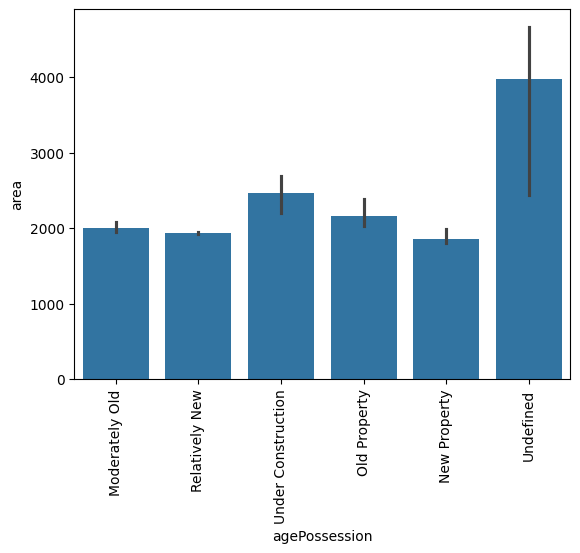

In [ ]:
sns.barplot(x=df['agePossession'],y=df['area'],estimator=np.median)
plt.xticks(rotation='vertical')
plt.show()

<Axes: xlabel='furnishing_type', ylabel='price'>

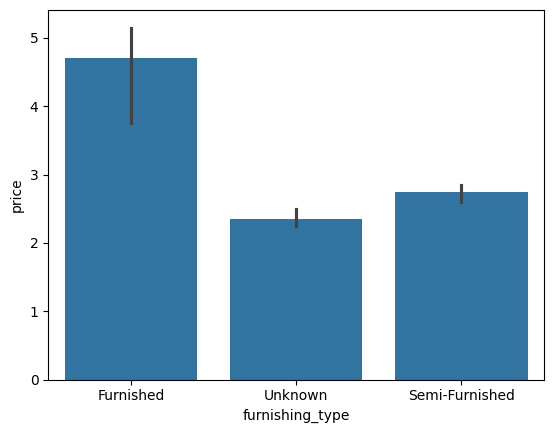

In [ ]:
sns.barplot(x=df['furnishing_type'],y=df['price'],estimator=np.median)

<Axes: xlabel='luxury_score', ylabel='price'>

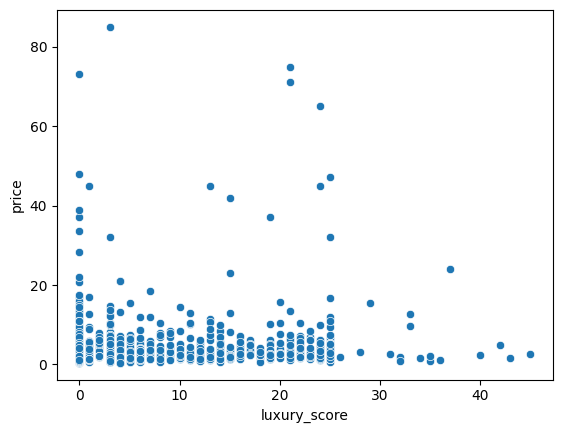

In [ ]:
sns.scatterplot(x=df['luxury_score'],y=df['price'])

# **Correlation**

<Axes: >

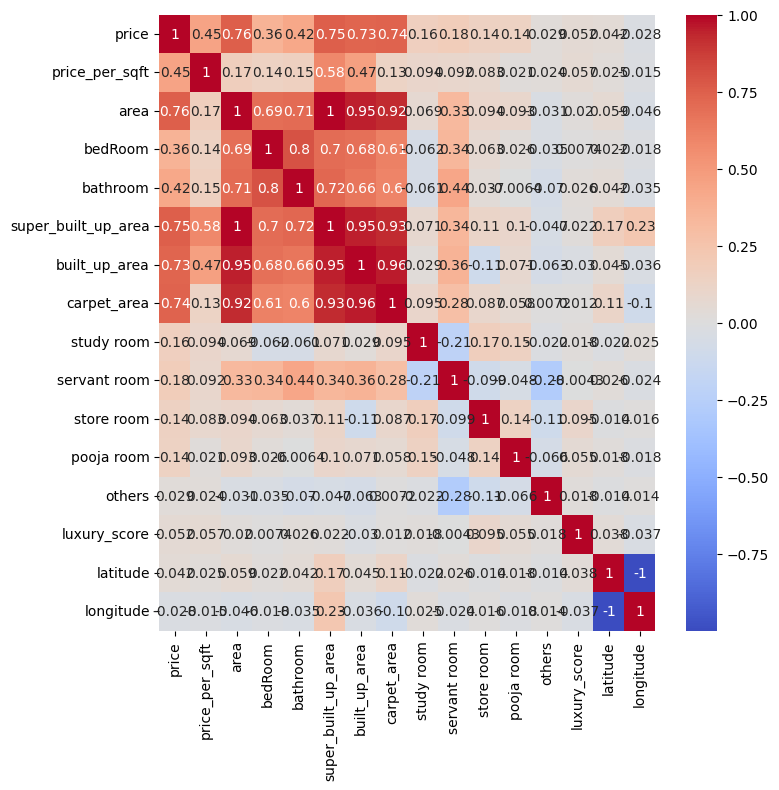

In [ ]:
plt.figure(figsize=(8,8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')

In [ ]:
df.select_dtypes(include='number').corr()['price'].sort_values(ascending=False)

,price
price,1.000000
area,0.756903
super_built_up_area,0.753049
carpet_area,0.741490
built_up_area,0.731097
price_per_sqft,0.447257
bathroom,0.424963
bedRoom,0.360207
servant room,0.182259
study room,0.163972


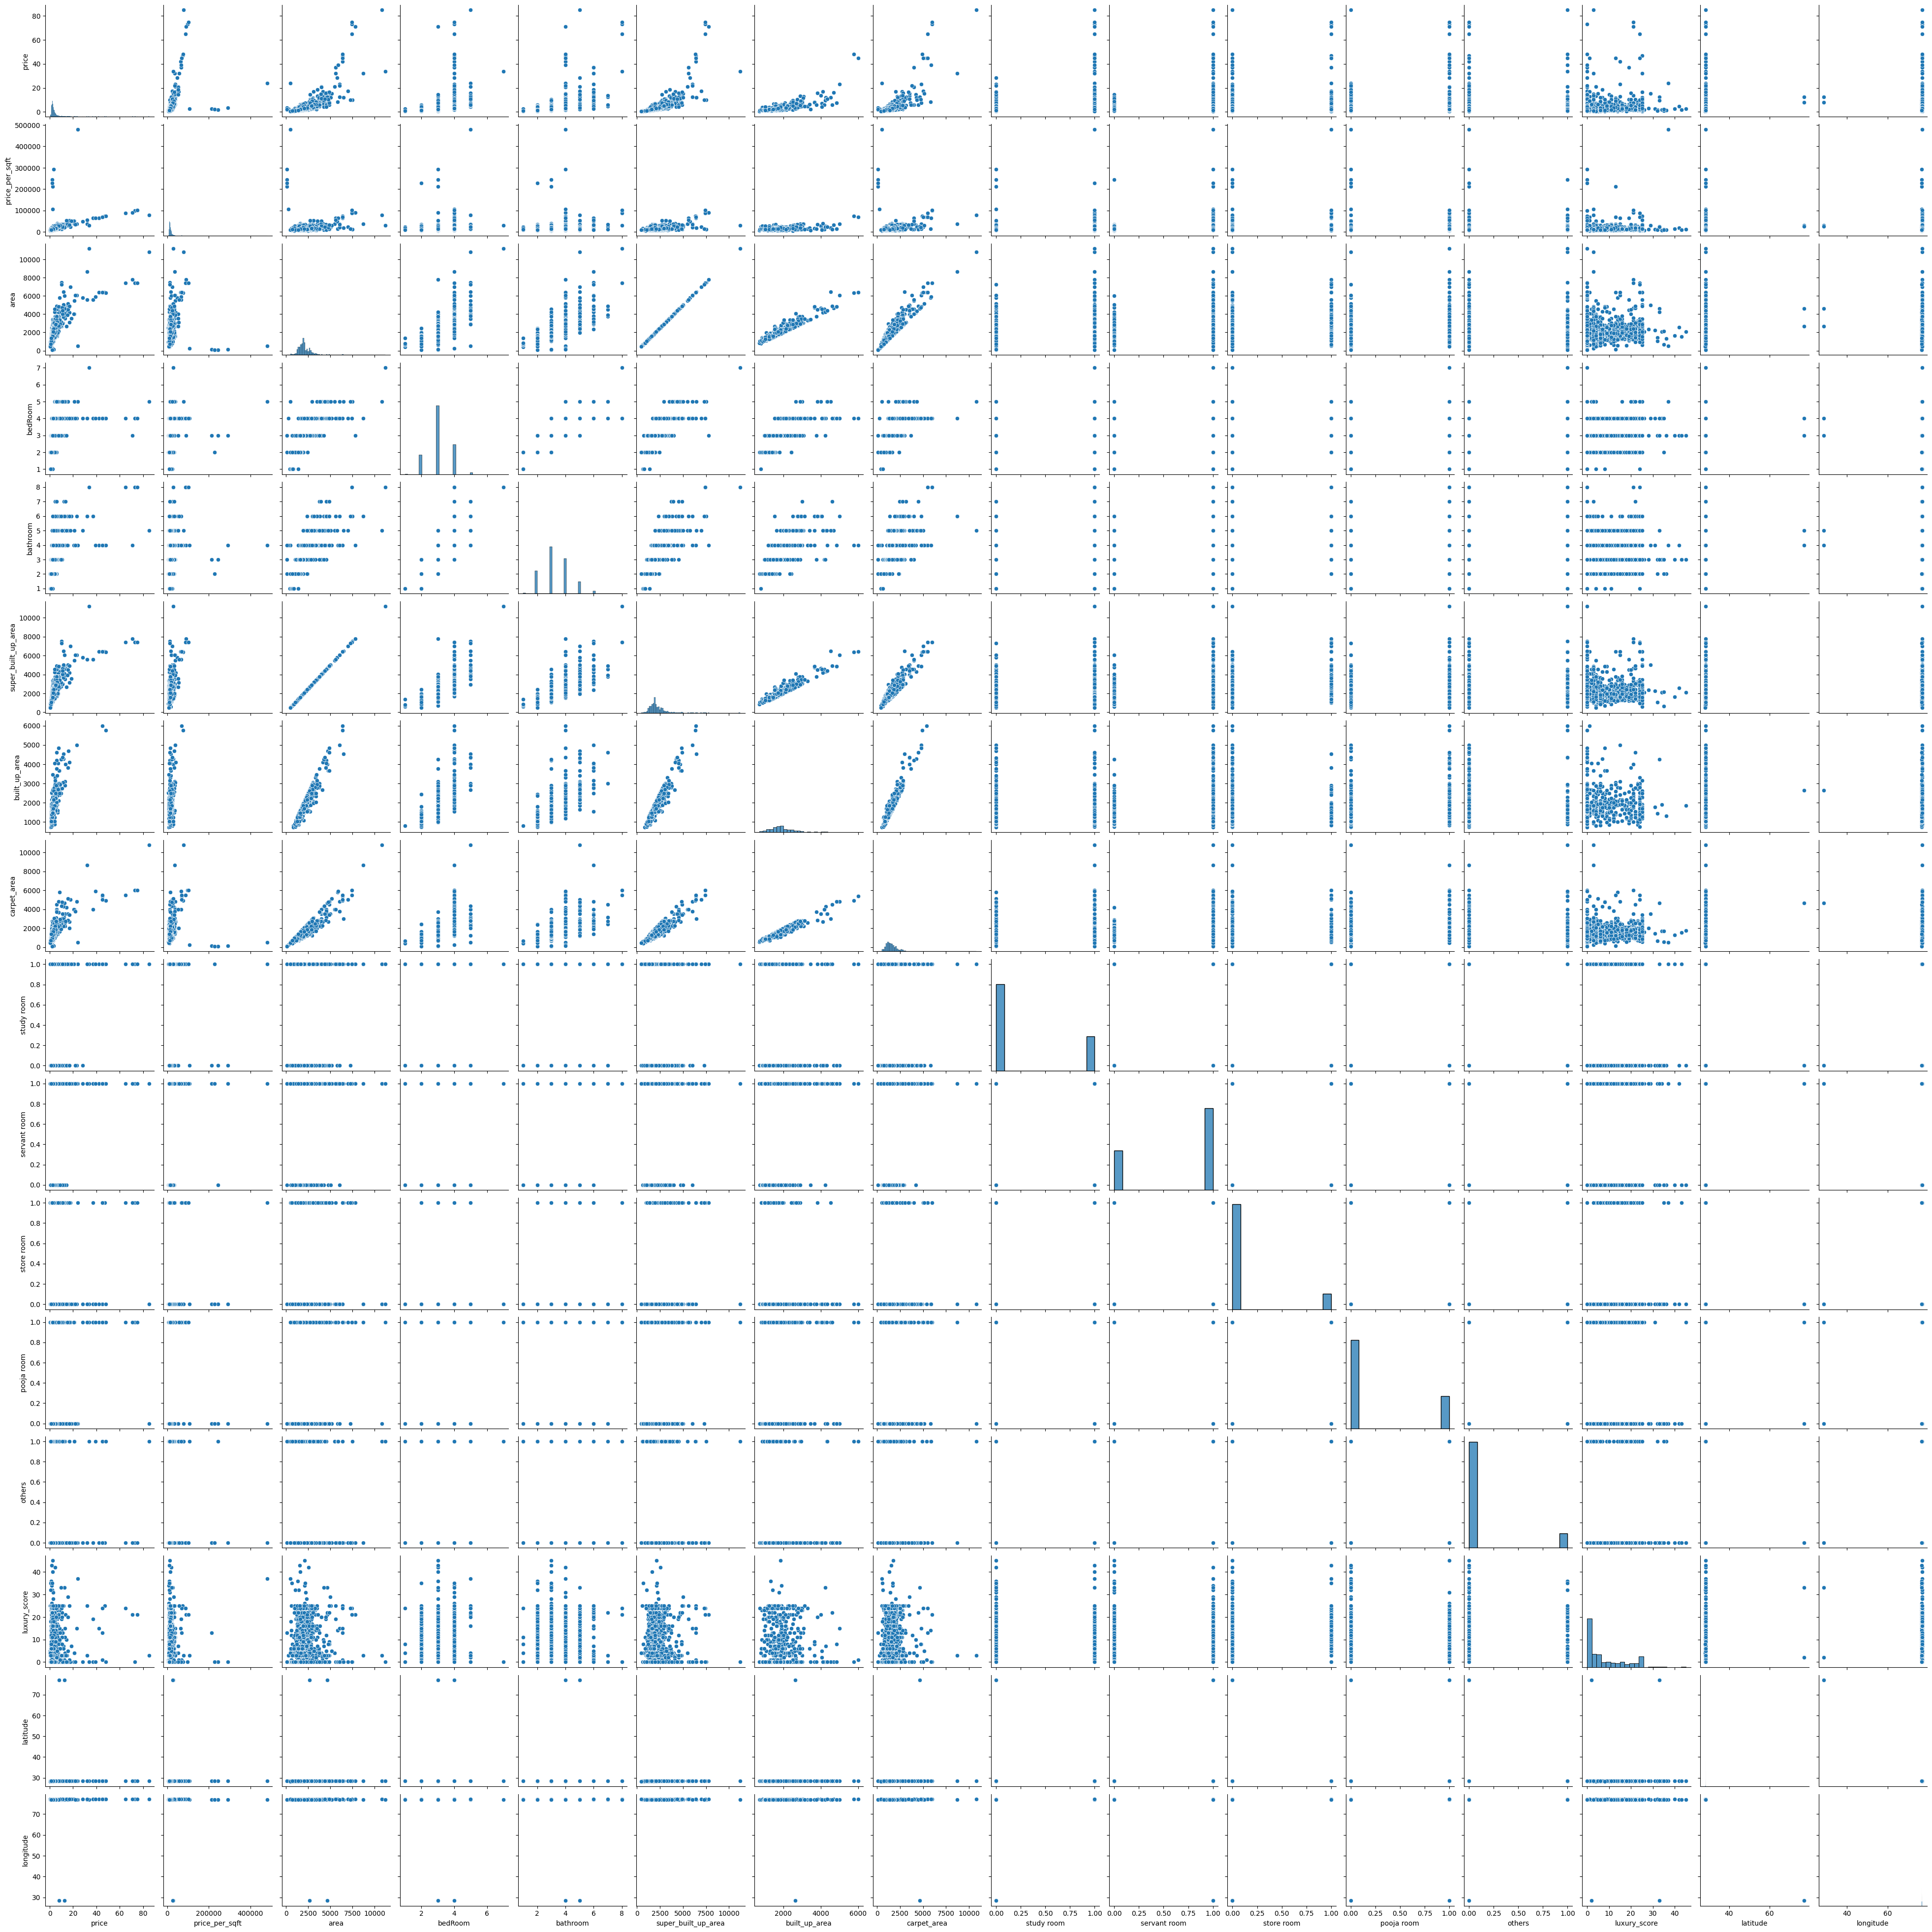

In [ ]:
sns.pairplot(df)